In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## expladatory data analysis

In [82]:
df = pd.read_csv("messy_food_waste.csv")

print(df.head())
print(df.shape) # (1560, 11)
print(df.columns)

# target = food_waste_kg

         date meals_served kitchen_staff  temperature_C  humidity_percent  \
0  2024-08-26           89             8          27.68             74.25   
1  2024-01-29          217             6          26.77             47.76   
2  2024-12-19          192             8            NaN             71.50   
3  2024-02-18          191             7            NaN             55.18   
4  2024-06-24          325            16          20.02             63.79   

   day_of_week  special_event  past_waste_kg staff_experience waste_category  \
0            0              0          46.36     Intermediate     Vegetables   
1            0              1          49.84           Expert     Vegetables   
2            3              0          39.53         Beginner           Meat   
3            6              1          27.12     Intermediate         Grains   
4            0              0            NaN         Beginner         GRAINS   

   food_waste_kg  
0          36.29  
1          42.22  

In [83]:
for x in df.columns:
    print(x, " = ", df[x].dtypes)
    # need to know type of columns

date  =  str
meals_served  =  str
kitchen_staff  =  str
temperature_C  =  float64
humidity_percent  =  float64
day_of_week  =  int64
special_event  =  int64
past_waste_kg  =  float64
staff_experience  =  str
waste_category  =  str
food_waste_kg  =  float64


In [84]:
miss = df.isnull().sum() / len(df) * 100 # how many percent of the feature is missing
print(miss)

duplicates = df.duplicated().sum()
print(duplicates) # 37 bor ekan

# meals_served        5.064103  str -> intga otqazishimiz kerak
# kitchen_staff       4.935897  str -> intga otqazish kerak
# temperature_C       7.884615  float64
# past_waste_kg       8.012821  float64
# staff_experience    7.884615  str -> format is different need to make everything lowercase and keyin normilize qisak boladi
# waste_category  =  str -> bu ham messy lowercase qilish kere
# not much we can fill everything

df = df.copy()

date                0.000000
meals_served        5.064103
kitchen_staff       4.935897
temperature_C       7.884615
humidity_percent    0.000000
day_of_week         0.000000
special_event       0.000000
past_waste_kg       8.012821
staff_experience    7.884615
waste_category      0.000000
food_waste_kg       0.000000
dtype: float64
37


## Filling missing values

In [85]:
# kitchen_staff va meals_servedni ni ichida: 10 staff yoki staff: 8 ga ohshaganlari bor ekan, shuni ichidan raqam chiqarib olamiz
# clean meals_served
df["meals_served"] = (df["meals_served"].astype(str).str.extract(r"(\d+(?:\.\d+)?)")[0])

# clean kitchen_staff
df["kitchen_staff"] = (df["kitchen_staff"].astype(str).str.extract(r"(\d+(?:\.\d+)?)")[0])

# str to numeric(float)
df["meals_served"] = pd.to_numeric(df["meals_served"], errors="coerce")
df["kitchen_staff"] = pd.to_numeric(df["kitchen_staff"], errors="coerce")

# filling with meadian
df["meals_served"] = df["meals_served"].fillna(df["meals_served"].median())
df["kitchen_staff"] = df["kitchen_staff"].fillna(df["kitchen_staff"].median())

# now need to convert to int
# chunki odam 1.5 ta odam bololmidi
df["meals_served"] = df["meals_served"].astype(int)
df["kitchen_staff"] = df["kitchen_staff"].astype(int)

In [86]:
# filling temperature_C and past_waste_kg
df["temperature_C"] = df["temperature_C"].fillna(df["temperature_C"].median())
df["past_waste_kg"] = df["past_waste_kg"].fillna(df["past_waste_kg"].median())

In [87]:
# clean staff_experience
df["staff_experience"] = (df["staff_experience"].str.strip().str.lower())
# fill missing values with mode
df["staff_experience"] = df["staff_experience"].fillna(df["staff_experience"].mode()[0])

# clean waste_category
df["waste_category"] = (df["waste_category"].str.strip().str.lower())
# fill missing values with mode
df["waste_category"] = df["waste_category"].fillna(df["waste_category"].mode()[0])


miss = df.isnull().sum() / len(df) * 100 # check one more time
print(miss) # 0 missing values

df = df.drop_duplicates() # drop duplicates
duplicates = df.duplicated().sum() # check one more time
print(duplicates) # 0 duplicates

df = df.copy()

date                0.0
meals_served        0.0
kitchen_staff       0.0
temperature_C       0.0
humidity_percent    0.0
day_of_week         0.0
special_event       0.0
past_waste_kg       0.0
staff_experience    0.0
waste_category      0.0
food_waste_kg       0.0
dtype: float64
0


## Fix unreal values

In [88]:
# fix impossible humidity values
df.loc[(df["humidity_percent"] < 0) | (df["humidity_percent"] > 100), "humidity_percent"] = np.nan

# fix impossible past waste values
df.loc[df["past_waste_kg"] < 0, "past_waste_kg"] = np.nan

# fill the new missing values with median
df["humidity_percent"] = df["humidity_percent"].fillna(df["humidity_percent"].median())

df["past_waste_kg"] = df["past_waste_kg"].fillna(df["past_waste_kg"].median())

In [89]:
df.shape # (1560, 11) - > (1523, 11)
df['day_of_week'].dtypes

dtype('int64')

## Outlierla ob tashlash

In [90]:
# 'date', 'meals_served', 'kitchen_staff', 'temperature_C',
#  'humidity_percent', 'day_of_week', 'special_event', 'past_waste_kg',
#  'staff_experience', 'waste_category', 'food_waste_kg'

# target food_waste_kg

# numerical features for outlier detection
numerical_columns = [
    "meals_served",
    "kitchen_staff",
    "temperature_C",
    "humidity_percent",
    "past_waste_kg"
]

# remove outliers from features
for x in numerical_columns:
    Q1 = df[x].quantile(0.25)
    Q3 = df[x].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[x] >= lower) & (df[x] <= upper)]

# handle target outliers separately
Q1 = df["food_waste_kg"].quantile(0.25)
Q3 = df["food_waste_kg"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["food_waste_kg"] >= lower) & (df["food_waste_kg"] <= upper)]

print("Shape after outlier removal:", df.shape)

# oldin 132 rows / 8.7% prosto ochirib tashagandim feature outliers ni target outliers dan ajratmasdan

Shape after outlier removal: (1419, 11)


## Feature engineering

In [91]:
# date ni togirlash kere
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

# how many meals each staff served
df["meals_per_staff"] = df["meals_served"] / df["kitchen_staff"]

print(df[["date", "month", "day", "meals_per_staff"]].head())

df = df.copy()

        date  month   day  meals_per_staff
0 2024-08-26    8.0  26.0        11.125000
1 2024-01-29    1.0  29.0        36.166667
2 2024-12-19   12.0  19.0        24.000000
3 2024-02-18    2.0  18.0        27.285714
4 2024-06-24    6.0  24.0        20.312500


## Encoding

In [92]:
# ordinal encoding for staff experience
experience_map = {
    "beginner": 0,
    "intermediate": 1,
    "expert": 2
}

df["experience_encoded"] = df["staff_experience"].map(experience_map)

# one - hot encoding for waste category (ovqat nomlari)
df = pd.get_dummies(
    df,
    columns=["waste_category"],
    dtype=int
)

df = df.copy()

print(df.head())
print(df.columns)

        date  meals_served  kitchen_staff  temperature_C  humidity_percent  \
0 2024-08-26            89              8          27.68             74.25   
1 2024-01-29           217              6          26.77             47.76   
2 2024-12-19           192              8          22.79             71.50   
3 2024-02-18           191              7          22.79             55.18   
4 2024-06-24           325             16          20.02             63.79   

   day_of_week  special_event  past_waste_kg staff_experience  food_waste_kg  \
0            0              0          46.36     intermediate          36.29   
1            0              1          49.84           expert          42.22   
2            3              0          39.53         beginner          39.81   
3            6              1          27.12     intermediate          40.75   
4            0              0          30.74         beginner          36.78   

   month   day  meals_per_staff  experience_encode

## EDA

In [93]:
# dataset information
df.info()

# numerical statistics
print(df.describe())

<class 'pandas.DataFrame'>
Index: 1419 entries, 0 to 1559
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1386 non-null   datetime64[us]
 1   meals_served               1419 non-null   int64         
 2   kitchen_staff              1419 non-null   int64         
 3   temperature_C              1419 non-null   float64       
 4   humidity_percent           1419 non-null   float64       
 5   day_of_week                1419 non-null   int64         
 6   special_event              1419 non-null   int64         
 7   past_waste_kg              1419 non-null   float64       
 8   staff_experience           1419 non-null   str           
 9   food_waste_kg              1419 non-null   float64       
 10  month                      1386 non-null   float64       
 11  day                        1386 non-null   float64       
 12  meals_per_staff       

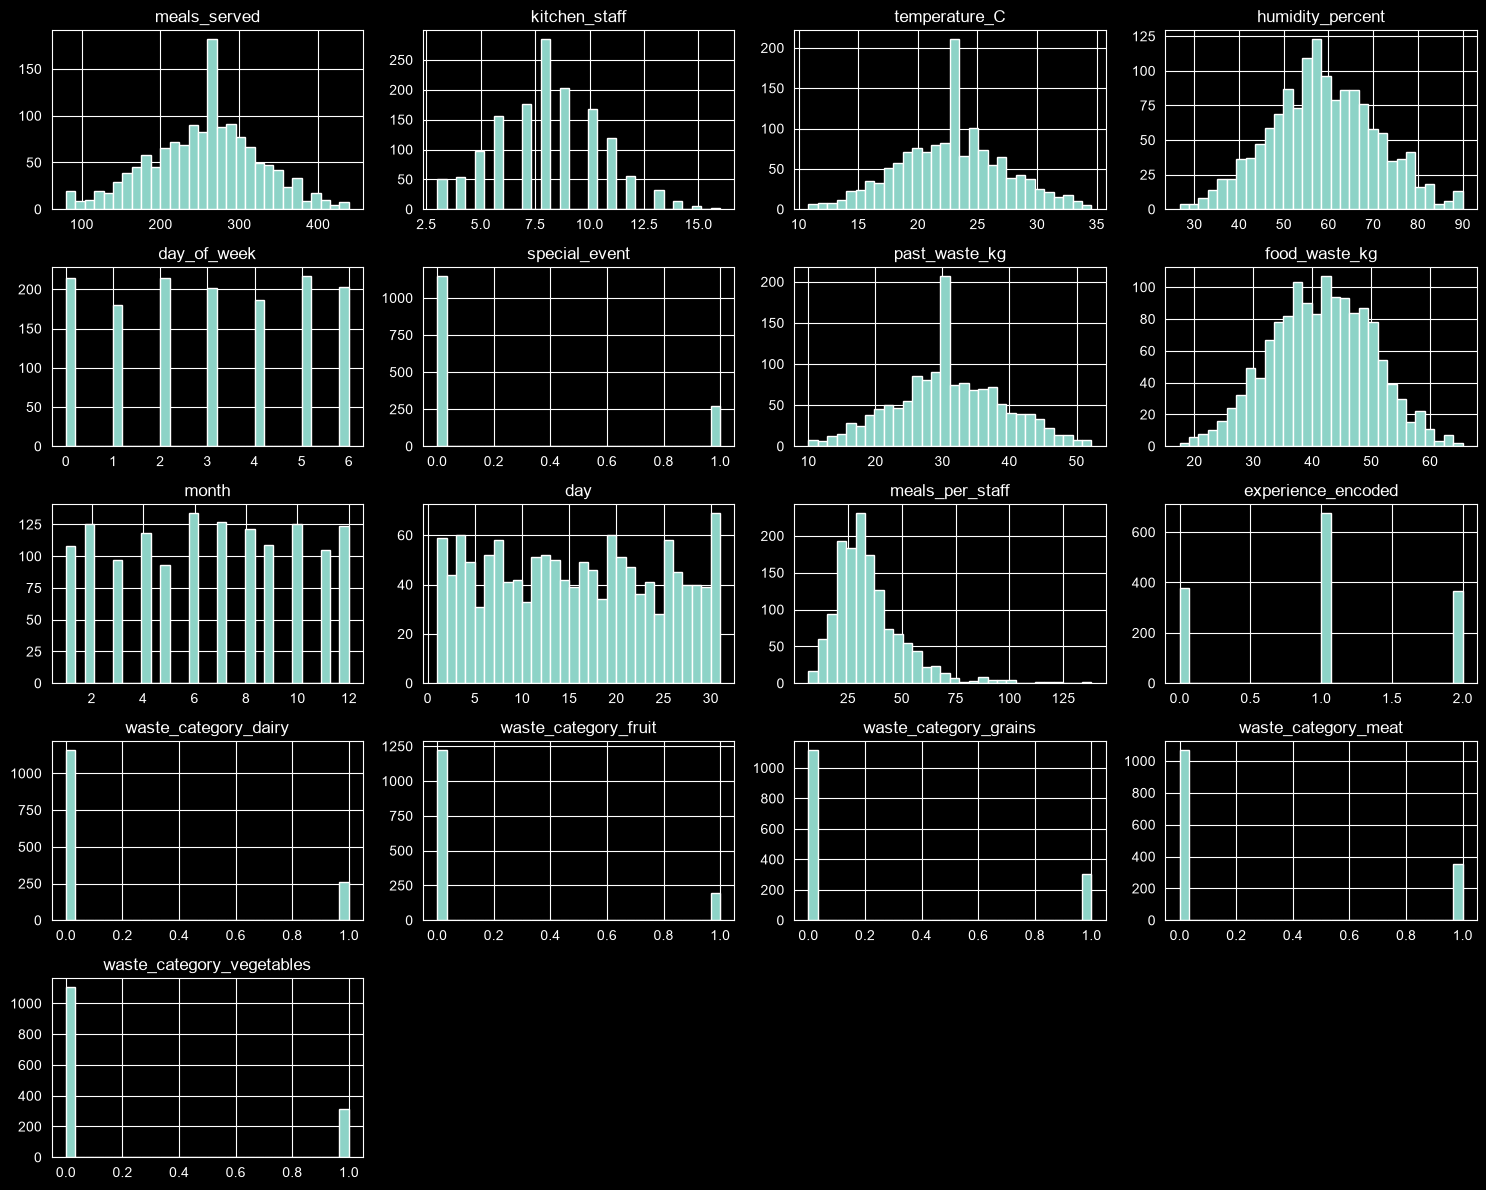

In [94]:
# histogram
df.select_dtypes(include="number").hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

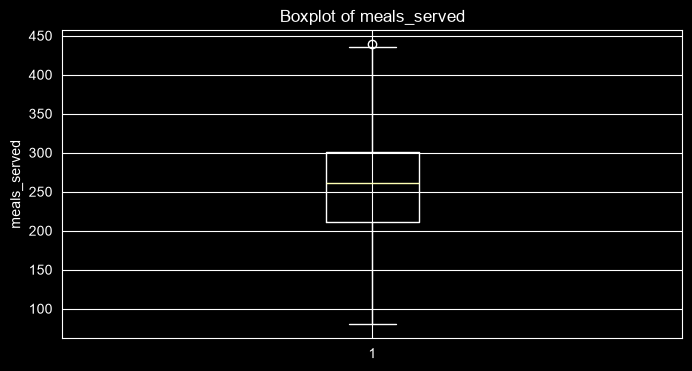

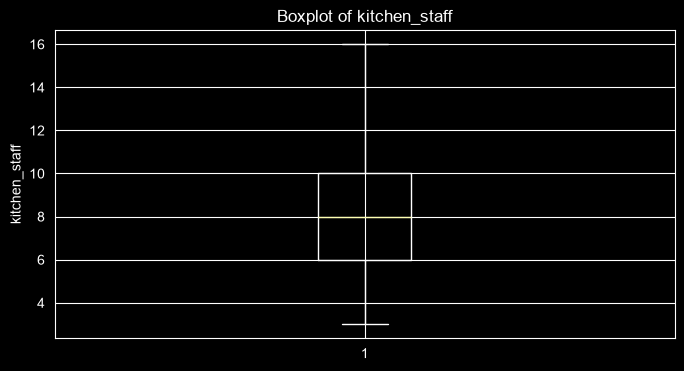

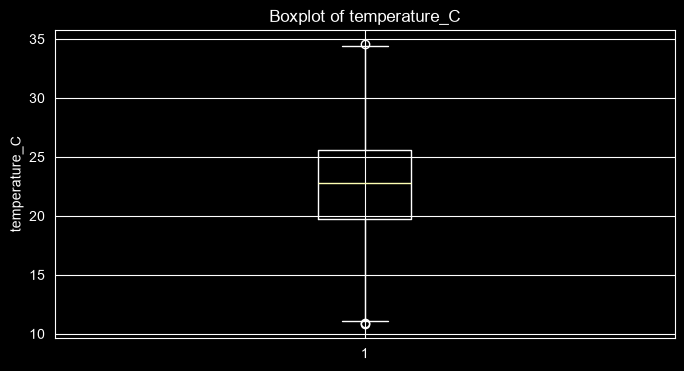

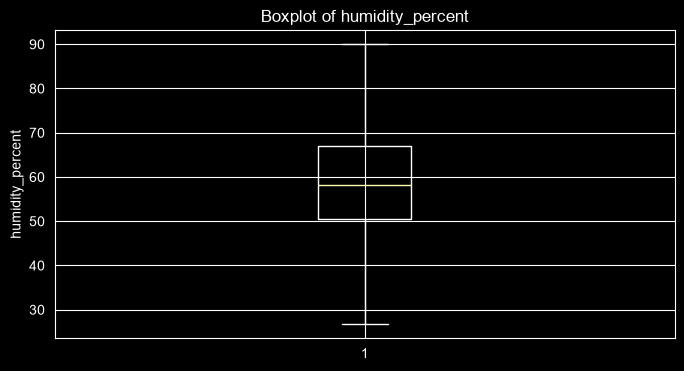

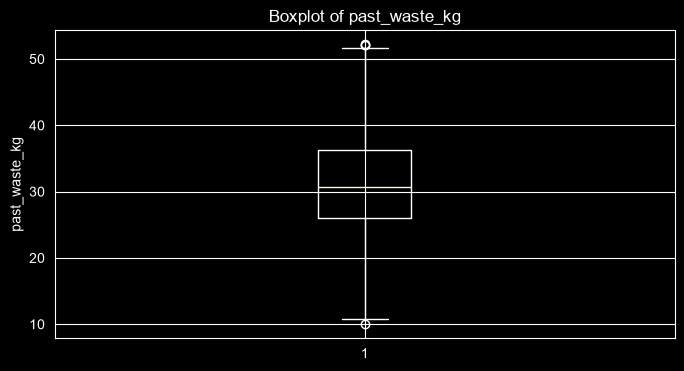

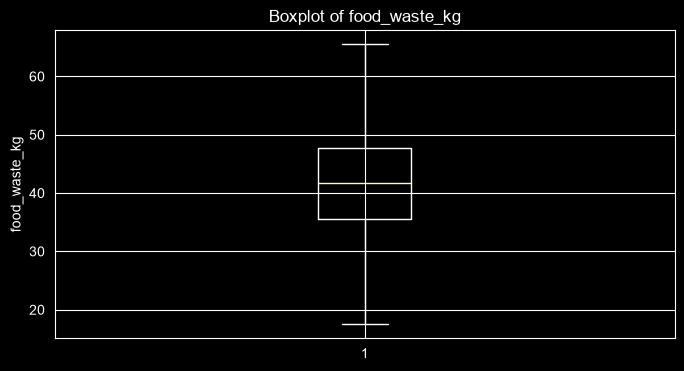

In [95]:
# boxplot
numerical_columns = [
    "meals_served",
    "kitchen_staff",
    "temperature_C",
    "humidity_percent",
    "past_waste_kg",
    "food_waste_kg"
]

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column])
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

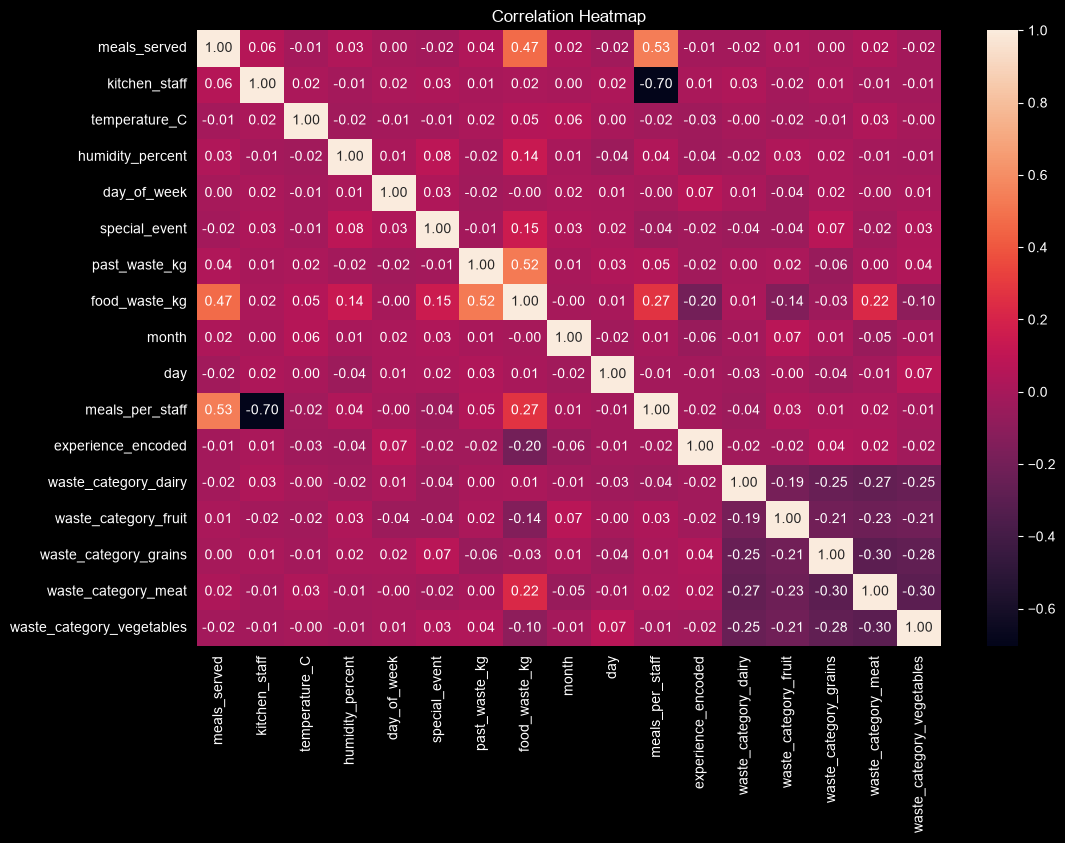

In [96]:
# heatmap
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Boglanishlar

In [97]:
corr = df.select_dtypes(include="number").corr()

print(corr["food_waste_kg"].sort_values(ascending=False))


df = df.copy()

food_waste_kg                1.000000
past_waste_kg                0.521884
meals_served                 0.473342
meals_per_staff              0.273537
waste_category_meat          0.223434
special_event                0.149061
humidity_percent             0.140166
temperature_C                0.051608
kitchen_staff                0.018910
waste_category_dairy         0.013901
day                          0.006124
month                       -0.003859
day_of_week                 -0.004157
waste_category_grains       -0.032028
waste_category_vegetables   -0.095088
waste_category_fruit        -0.142645
experience_encoded          -0.201136
Name: food_waste_kg, dtype: float64


In [98]:
df.to_csv("messy_food_waste_cleaned.csv", index=False)

print(df.shape) # (1419, 19)

(1419, 19)
